عکس با موفقیت لود شد.


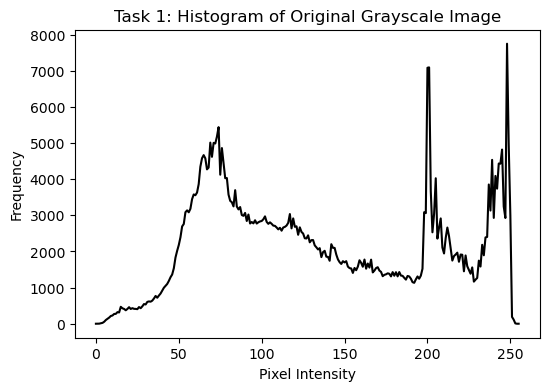

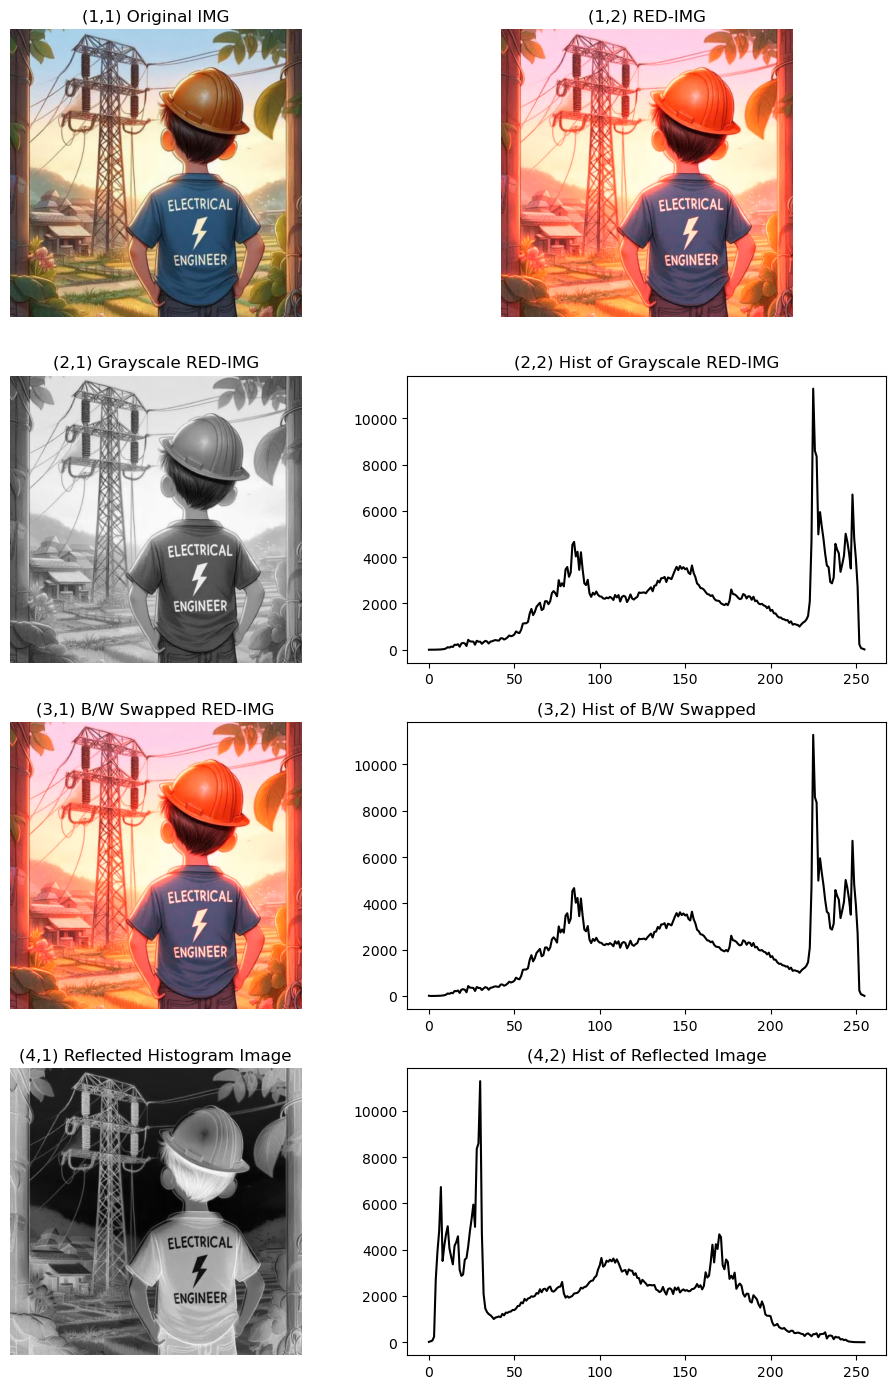

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class ImageProcessor:
    def __init__(self, image_path):
      
        self.img = cv2.imread(image_path)
       
        if self.img is not None:
            print("عکس با موفقیت لود شد.")
            self.img_rgb = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)
            self.is_loaded = True
        else:
            print("فایل عکس پیدا نشد یا فرمت آن مناسب نیست. ")
            self.is_loaded = False

    def plot_task1_histogram(self):
        """بخش اول: رسم هیستوگرام خاکستری تصویر اصلی"""
        # تبدیل عکس به سیاه و سفید (خاکستری)
        gray = cv2.cvtColor(self.img_rgb, cv2.COLOR_RGB2GRAY)
        
        # محاسبه هیستوگرام
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        
        plt.figure(figsize=(6, 4))
        plt.plot(hist, color='black')
        plt.title("Task 1: Histogram of Original Grayscale Image")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.show()

    def run_subplots(self):
        
        fig, axs = plt.subplots(4, 2, figsize=(10, 14))
        
    
        axs[0, 0].imshow(self.img_rgb)
        axs[0, 0].set_title("(1,1) Original IMG")
        axs[0, 0].axis('off')
        
        
        red_img = self.img_rgb.copy()
        
        red_channel = red_img[:, :, 0] * 2.0
        red_channel[red_channel > 255] = 255 
        red_img[:, :, 0] = red_channel
        
        axs[0, 1].imshow(red_img)
        axs[0, 1].set_title("(1,2) RED-IMG")
        axs[0, 1].axis('off')
        
       
        
        red_gray = cv2.cvtColor(red_img, cv2.COLOR_RGB2GRAY)
        axs[1, 0].imshow(red_gray, cmap='gray')
        axs[1, 0].set_title("(2,1) Grayscale RED-IMG")
        axs[1, 0].axis('off')
        
        
        hist_red_gray = cv2.calcHist([red_gray], [0], None, [256], [0, 256])
        axs[1, 1].plot(hist_red_gray, color='black')
        axs[1, 1].set_title("(2,2) Hist of Grayscale RED-IMG")
        
        
        
        bw_swapped = red_img.copy()
        
        
        is_black = (bw_swapped[:,:,0]==0) & (bw_swapped[:,:,1]==0) & (bw_swapped[:,:,2]==0)
        is_white = (bw_swapped[:,:,0]==255) & (bw_swapped[:,:,1]==255) & (bw_swapped[:,:,2]==255)
        
        bw_swapped[is_black] = [255, 255, 255] 
        bw_swapped[is_white] = [0, 0, 0]        
        
        axs[2, 0].imshow(bw_swapped)
        axs[2, 0].set_title("(3,1) B/W Swapped RED-IMG")
        axs[2, 0].axis('off')
        
        bw_gray = cv2.cvtColor(bw_swapped, cv2.COLOR_RGB2GRAY)
        hist_bw = cv2.calcHist([bw_gray], [0], None, [256], [0, 256])
        axs[2, 1].plot(hist_bw, color='black')
        axs[2, 1].set_title("(3,2) Hist of B/W Swapped")
        
        
        reflected_gray = 255 - red_gray
        axs[3, 0].imshow(reflected_gray, cmap='gray')
        axs[3, 0].set_title("(4,1) Reflected Histogram Image")
        axs[3, 0].axis('off')
        
      
        hist_reflected = cv2.calcHist([reflected_gray], [0], None, [256], [0, 256])
        axs[3, 1].plot(hist_reflected, color='black')
        axs[3, 1].set_title("(4,2) Hist of Reflected Image")

        plt.tight_layout()
        plt.show()


processor = ImageProcessor('ele.png')
if processor.is_loaded:
    # رسم هیستوگرام خاکستری (بخش اول)
    processor.plot_task1_histogram()

    # رسم چیدمان 4 در 2 (بخش دوم)
    processor.run_subplots()